# 01 — Simple EDA before the first submission

目的は、データ契約・目的変数・欠損を短時間で確認し、最初の XGBoost submission へ進める状態を作ることです。別コンペでも、まず同じチェックを行います。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
TRAIN_PATH = ROOT / "input" / "train.csv"
TEST_PATH = ROOT / "input" / "test.csv"
TARGET = "Transported"
ID_COLUMN = "PassengerId"
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
train.shape, test.shape

((8693, 14), (4277, 13))

## Data contract
train/test の列差、ID 重複、目的変数の存在を最初に検証します。列名は別コンペでは設定値へ置き換えます。

In [2]:
assert TARGET in train and TARGET not in test
assert train[ID_COLUMN].is_unique and test[ID_COLUMN].is_unique
assert set(train.columns) - {TARGET} == set(test.columns)
pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(train), len(test)],
        "columns": [train.shape[1], test.shape[1]],
        "duplicate_ids": [train[ID_COLUMN].duplicated().sum(), test[ID_COLUMN].duplicated().sum()],
    }
)

,dataset,rows,columns,duplicate_ids
0,train,8693,14,0
1,test,4277,13,0


In [3]:
target_summary = train[TARGET].value_counts(dropna=False).rename_axis(TARGET).to_frame("count")
target_summary["rate"] = target_summary["count"] / len(train)
target_summary

,count,rate
Transported,,
True,4378,0.503624
False,4315,0.496376


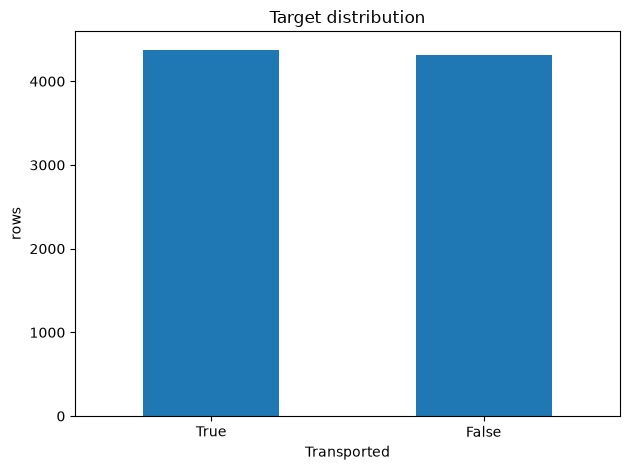

In [4]:
ax = target_summary["count"].plot.bar(title="Target distribution", rot=0)
ax.set_ylabel("rows")
plt.tight_layout()
plt.show()

## Dtypes and missingness
欠損率だけでなく train/test の差を並べます。大きな差があれば詳細 EDA の adversarial validation で確認します。

In [5]:
feature_columns = [c for c in train.columns if c != TARGET]
schema = pd.DataFrame(
    {
        "dtype": train[feature_columns].dtypes.astype(str),
        "train_missing_n": train[feature_columns].isna().sum(),
        "train_missing_rate": train[feature_columns].isna().mean(),
        "test_missing_n": test[feature_columns].isna().sum(),
        "test_missing_rate": test[feature_columns].isna().mean(),
    }
)
schema["missing_rate_gap"] = (schema["train_missing_rate"] - schema["test_missing_rate"]).abs()
schema.sort_values("train_missing_rate", ascending=False)

,dtype,train_missing_n,train_missing_rate,test_missing_n,test_missing_rate,missing_rate_gap
CryoSleep,object,217,0.024963,93,0.021744,0.003218
ShoppingMall,float64,208,0.023927,98,0.022913,0.001014
VIP,object,203,0.023352,93,0.021744,0.001608
HomePlanet,str,201,0.023122,87,0.020341,0.002781
Name,str,200,0.023007,94,0.021978,0.001029
Cabin,str,199,0.022892,100,0.023381,0.000489
VRDeck,float64,188,0.021627,80,0.018705,0.002922
FoodCourt,float64,183,0.021051,106,0.024784,0.003732
Spa,float64,183,0.021051,101,0.023615,0.002563
Destination,str,182,0.020936,92,0.021510,0.000574


In [6]:
numeric_summary = train.describe(include="number").T
categorical_summary = train.describe(include=["object", "string", "bool"]).T
display(numeric_summary)
display(categorical_summary)

,count,mean,std,min,25%,50%,75%,max
Age,8514.0,28.827930,14.489021,0.0,19.0,27.0,38.0,79.0
RoomService,8512.0,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0
FoodCourt,8510.0,458.077203,1611.489240,0.0,0.0,0.0,76.0,29813.0
ShoppingMall,8485.0,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0
Spa,8510.0,311.138778,1136.705535,0.0,0.0,0.0,59.0,22408.0
VRDeck,8505.0,304.854791,1145.717189,0.0,0.0,0.0,46.0,24133.0


,count,unique,top,freq
PassengerId,8693,8693,0001_01,1
HomePlanet,8492,3,Earth,4602
CryoSleep,8476,2,False,5439
Cabin,8494,6560,G/734/S,8
Destination,8511,3,TRAPPIST-1e,5915
VIP,8490,2,False,8291
Name,8493,8473,Elaney Webstephrey,2
Transported,8693,2,True,4378


## First experiment decision
目的変数はほぼ均衡しているため、最初は accuracy、閾値 0.5、通常の shuffled StratifiedKFold、one-hot + XGBoost とします。これはパイプライン疎通確認用であり、group leakage を監査するまでは CV を最終判断に使いません。

実行: `uv run python train.py --config configs/exp001_xgb_initial.yaml`